In [1]:
import pennylane as qml
import torch
import numpy as np

print(f"PennyLane version: {qml.version()}")
print(f"PyTorch version: {torch.__version__}")
print(f"NumPy version: {np.__version__}")
print("\n✅ All quantum ML libraries ready!")

PennyLane version: 0.45.0
PyTorch version: 2.12.0+cpu
NumPy version: 2.4.6

✅ All quantum ML libraries ready!


In [2]:
import pennylane as qml
import numpy as np
import matplotlib.pyplot as plt

# Create a quantum device with 2 qubits
dev = qml.device("default.qubit", wires=2)

# Define a Quantum Neural Network
@qml.qnode(dev)
def quantum_neural_network(inputs, weights):
    """
    A simple quantum neural network.
    - inputs: classical data point [x, y]
    - weights: trainable parameters
    """
    
    # ENCODE: Put classical data into quantum state
    qml.RY(inputs[0], wires=0)
    qml.RY(inputs[1], wires=1)
    
    # ENTANGLE: Make qubits interact
    qml.CNOT(wires=[0, 1])
    
    # LEARN: Trainable rotation gates
    qml.RY(weights[0], wires=0)
    qml.RY(weights[1], wires=1)
    
    # More entanglement
    qml.CNOT(wires=[0, 1])
    
    # More learning
    qml.RY(weights[2], wires=0)
    qml.RY(weights[3], wires=1)
    
    # MEASURE: Get classification result
    return qml.expval(qml.PauliZ(0))


# Test it
test_input = np.array([0.5, 0.3])
test_weights = np.array([0.1, 0.2, 0.3, 0.4])

result = quantum_neural_network(test_input, test_weights)
print(f"Quantum NN output: {result}")
print("✅ Your quantum neural network works!")

Quantum NN output: 0.6694251311411115
✅ Your quantum neural network works!


In [3]:
# Draw the circuit
print(qml.draw(quantum_neural_network)(test_input, test_weights))

0: ──RY(0.50)─╭●──RY(0.10)─╭●──RY(0.30)─┤  <Z>
1: ──RY(0.30)─╰X──RY(0.20)─╰X──RY(0.40)─┤     


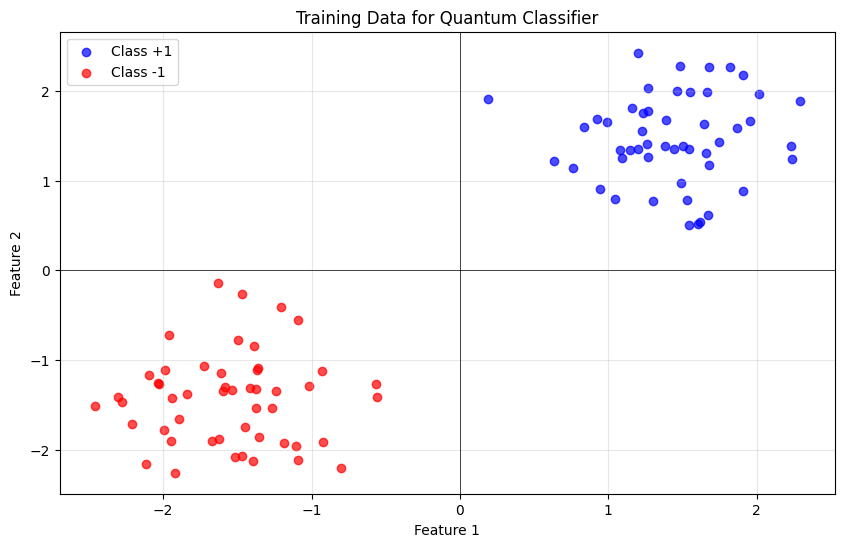


📊 Dataset created: 100 points, 2 classes


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Generate two classes of data (like a binary classification problem)
np.random.seed(42)

# Class 0: points in upper-right
class_0 = np.random.randn(50, 2) * 0.5 + np.array([1.5, 1.5])

# Class 1: points in lower-left
class_1 = np.random.randn(50, 2) * 0.5 + np.array([-1.5, -1.5])

# Combine into dataset
X = np.vstack([class_0, class_1])
y = np.hstack([np.ones(50), -np.ones(50)])  # +1 and -1 labels

# Visualize
plt.figure(figsize=(10, 6))
plt.scatter(class_0[:, 0], class_0[:, 1], c='blue', label='Class +1', alpha=0.7)
plt.scatter(class_1[:, 0], class_1[:, 1], c='red', label='Class -1', alpha=0.7)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Training Data for Quantum Classifier')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='black', linewidth=0.5)
plt.axvline(x=0, color='black', linewidth=0.5)
plt.show()

print(f"\n📊 Dataset created: {len(X)} points, 2 classes")

🧠 Training Quantum Neural Network...

Step   0 | Loss: 1.6196
Step  10 | Loss: 0.1520
Step  20 | Loss: 0.0536
Step  30 | Loss: 0.0327
Step  40 | Loss: 0.0259

✅ Training complete!
Final weights: [ 0.10143959  0.06449232 -1.42375424  0.4       ]


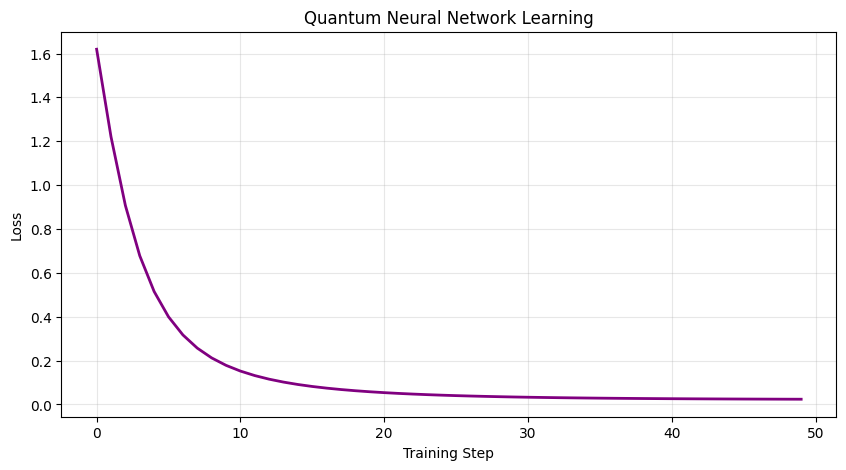

In [5]:
from pennylane import numpy as pnp  # PennyLane's NumPy (supports gradients)

# Cost function — how wrong is our quantum NN?
def cost(weights, X, y):
    predictions = [quantum_neural_network(x, weights) for x in X]
    predictions = pnp.array(predictions)
    return pnp.mean((predictions - y) ** 2)

# Initialize random weights
weights = pnp.array([0.1, 0.2, 0.3, 0.4], requires_grad=True)

# Optimizer
opt = qml.GradientDescentOptimizer(stepsize=0.1)

# Training loop
print("🧠 Training Quantum Neural Network...\n")
costs = []

for step in range(50):
    weights, loss = opt.step_and_cost(lambda w: cost(w, X, y), weights)
    costs.append(loss)
    
    if step % 10 == 0:
        print(f"Step {step:3d} | Loss: {loss:.4f}")

print(f"\n✅ Training complete!")
print(f"Final weights: {weights}")

# Plot training progress
plt.figure(figsize=(10, 5))
plt.plot(costs, color='purple', linewidth=2)
plt.xlabel('Training Step')
plt.ylabel('Loss')
plt.title('Quantum Neural Network Learning')
plt.grid(True, alpha=0.3)
plt.show()

In [6]:
# Test on training data
correct = 0
for x, true_label in zip(X, y):
    prediction = quantum_neural_network(x, weights)
    predicted_class = 1 if prediction > 0 else -1
    if predicted_class == true_label:
        correct += 1

accuracy = correct / len(X) * 100
print(f"🎯 Accuracy: {accuracy:.1f}% ({correct}/{len(X)} correct)")

# Test on NEW points it hasn't seen
print("\n🔮 Predicting new points:")
new_points = [
    np.array([2.0, 1.5]),     # Should be class +1
    np.array([-1.5, -2.0]),   # Should be class -1
    np.array([0.0, 0.0]),     # Boundary case
    np.array([1.0, -1.0]),    # Mixed case
]

for point in new_points:
    pred = quantum_neural_network(point, weights)
    classification = "+1 (blue)" if pred > 0 else "-1 (red)"
    print(f"  Point {point}: prediction = {pred:.3f} → Class {classification}")

🎯 Accuracy: 100.0% (100/100 correct)

🔮 Predicting new points:
  Point [2.  1.5]: prediction = 0.778 → Class +1 (blue)
  Point [-1.5 -2. ]: prediction = -0.992 → Class -1 (red)
  Point [0. 0.]: prediction = 0.152 → Class +1 (blue)
  Point [ 1. -1.]: prediction = 0.874 → Class +1 (blue)


🌐 Computing quantum decision boundary...


C:\Users\harve\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


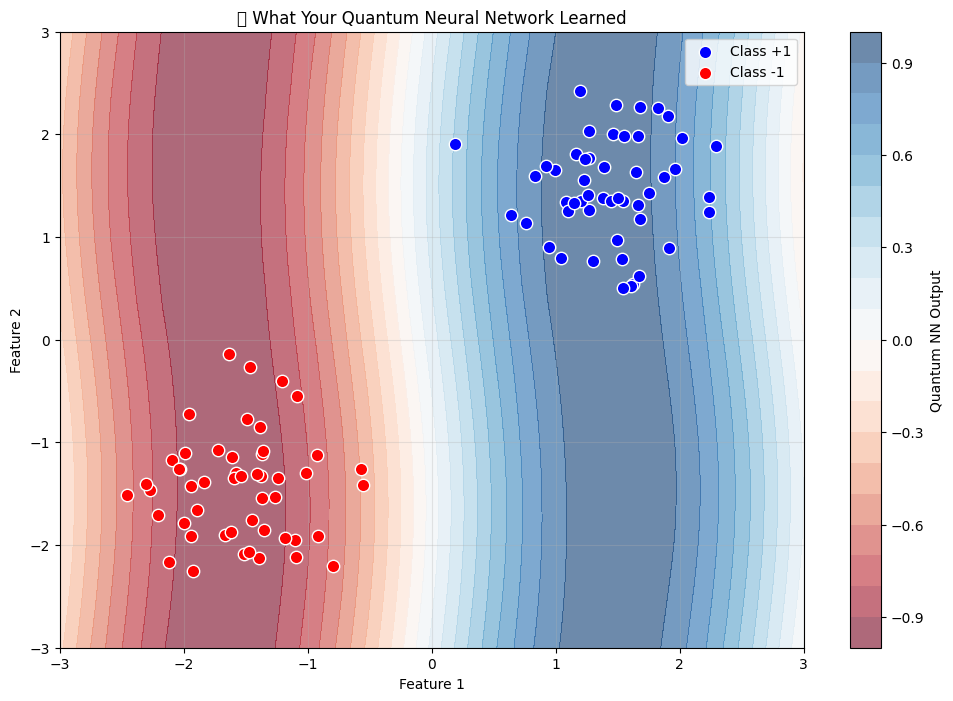


💡 The colored regions show how your quantum AI classifies space.
   Blue = predicts class +1
   Red = predicts class -1
   The boundary between them is what the AI 'learned'!


In [7]:
# Create a grid of points
x_range = np.linspace(-3, 3, 30)
y_range = np.linspace(-3, 3, 30)
xx, yy = np.meshgrid(x_range, y_range)

# Get quantum prediction for each grid point
print("🌐 Computing quantum decision boundary...")
predictions = np.zeros(xx.shape)
for i in range(xx.shape[0]):
    for j in range(xx.shape[1]):
        point = np.array([xx[i, j], yy[i, j]])
        predictions[i, j] = quantum_neural_network(point, weights)

# Plot decision boundary
plt.figure(figsize=(12, 8))
plt.contourf(xx, yy, predictions, levels=20, cmap='RdBu', alpha=0.6)
plt.colorbar(label='Quantum NN Output')

# Overlay training data
plt.scatter(class_0[:, 0], class_0[:, 1], c='blue', edgecolors='white',
            s=80, label='Class +1', zorder=5)
plt.scatter(class_1[:, 0], class_1[:, 1], c='red', edgecolors='white',
            s=80, label='Class -1', zorder=5)

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('🧠 What Your Quantum Neural Network Learned')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\n💡 The colored regions show how your quantum AI classifies space.")
print("   Blue = predicts class +1")
print("   Red = predicts class -1")
print("   The boundary between them is what the AI 'learned'!")

In [8]:
# Connect PennyLane to your IBM hardware
from pennylane import numpy as pnp

# Use IBM quantum hardware as the device
dev_ibm = qml.device(
    'qiskit.remote',
    wires=2,
    backend=backend,  # The backend you already set up!
    shots=1000
)

@qml.qnode(dev_ibm)
def quantum_nn_on_real_hardware(inputs, weights):
    qml.RY(inputs[0], wires=0)
    qml.RY(inputs[1], wires=1)
    qml.CNOT(wires=[0, 1])
    qml.RY(weights[0], wires=0)
    qml.RY(weights[1], wires=1)
    return qml.expval(qml.PauliZ(0))

# Test on real hardware (uses a bit of your IBM time)
test_point = np.array([1.5, 1.5])
test_weights = np.array([0.5, 0.3])

print("🌐 Running quantum neural network on REAL IBM quantum computer...")
result = quantum_nn_on_real_hardware(test_point, test_weights)
print(f"Result from real quantum hardware: {result}")

NameError: name 'backend' is not defined

In [9]:
from qiskit_ibm_runtime import QiskitRuntimeService

# Reconnect to your saved IBM account
service = QiskitRuntimeService()

# Get a backend
backend = service.least_busy(operational=True, simulator=False)

print(f"✅ Connected to: {backend.name}")
print(f"   Qubits: {backend.num_qubits}")
print(f"   Queue: {backend.status().pending_jobs} jobs")

✅ Connected to: ibm_marrakesh
   Qubits: 156
   Queue: 0 jobs


In [10]:
import pennylane as qml
import numpy as np

# Use IBM quantum hardware as the device
dev_ibm = qml.device(
    'qiskit.remote',
    wires=2,
    backend=backend,
    shots=1000
)

@qml.qnode(dev_ibm)
def quantum_nn_on_real_hardware(inputs, weights):
    qml.RY(inputs[0], wires=0)
    qml.RY(inputs[1], wires=1)
    qml.CNOT(wires=[0, 1])
    qml.RY(weights[0], wires=0)
    qml.RY(weights[1], wires=1)
    return qml.expval(qml.PauliZ(0))

# Test on real hardware
test_point = np.array([1.5, 1.5])
test_weights = np.array([0.5, 0.3])

print("🌐 Running quantum neural network on REAL IBM quantum computer...")
print("⏳ This will go in the queue and may take a few minutes...")

result = quantum_nn_on_real_hardware(test_point, test_weights)
print(f"\n✅ Result from real quantum hardware: {result}")

C:\Users\harve\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pennylane\devices\device_api.py:207: PennyLaneDeprecationWarning: Setting shots on device is deprecated. Please use the `set_shots` transform on the respective QNode instead.
  warnings.warn(


🌐 Running quantum neural network on REAL IBM quantum computer...
⏳ This will go in the queue and may take a few minutes...

✅ Result from real quantum hardware: -0.3765401675702316


In [11]:
import pennylane as qml
import numpy as np

# Local simulator (perfect, no noise)
dev_sim = qml.device("default.qubit", wires=2)

@qml.qnode(dev_sim)
def quantum_nn_simulator(inputs, weights):
    qml.RY(inputs[0], wires=0)
    qml.RY(inputs[1], wires=1)
    qml.CNOT(wires=[0, 1])
    qml.RY(weights[0], wires=0)
    qml.RY(weights[1], wires=1)
    return qml.expval(qml.PauliZ(0))

# Same inputs
test_point = np.array([1.5, 1.5])
test_weights = np.array([0.5, 0.3])

sim_result = quantum_nn_simulator(test_point, test_weights)

print("=" * 50)
print("  QUANTUM NEURAL NETWORK COMPARISON")
print("=" * 50)
print(f"  Simulator (perfect):   {sim_result:.4f}")
print(f"  Real Hardware (noisy): -0.3765")
print(f"  Difference (noise):    {abs(sim_result - (-0.3765)):.4f}")
print("=" * 50)
print("\n💡 The difference is REAL quantum noise from")
print("   superconducting qubits at 15 millikelvin!")

  QUANTUM NEURAL NETWORK COMPARISON
  Simulator (perfect):   -0.4149
  Real Hardware (noisy): -0.3765
  Difference (noise):    0.0384

💡 The difference is REAL quantum noise from
   superconducting qubits at 15 millikelvin!


In [12]:
import pennylane as qml
import numpy as np

# Local simulator (perfect, no noise)
dev_sim = qml.device("default.qubit", wires=2)

@qml.qnode(dev_sim)
def quantum_nn_simulator(inputs, weights):
    qml.RY(inputs[0], wires=0)
    qml.RY(inputs[1], wires=1)
    qml.CNOT(wires=[0, 1])
    qml.RY(weights[0], wires=0)
    qml.RY(weights[1], wires=1)
    return qml.expval(qml.PauliZ(0))

# Same inputs
test_point = np.array([1.5, 1.5])
test_weights = np.array([0.5, 0.3])

sim_result = quantum_nn_simulator(test_point, test_weights)

print("=" * 50)
print("  QUANTUM NEURAL NETWORK COMPARISON")
print("=" * 50)
print(f"  Simulator (perfect):   {sim_result:.4f}")
print(f"  Real Hardware (noisy): -0.3765")
print(f"  Difference (noise):    {abs(sim_result - (-0.3765)):.4f}")
print("=" * 50)
print("\n💡 The difference is REAL quantum noise from")
print("   superconducting qubits at 15 millikelvin!")

  QUANTUM NEURAL NETWORK COMPARISON
  Simulator (perfect):   -0.4149
  Real Hardware (noisy): -0.3765
  Difference (noise):    0.0384

💡 The difference is REAL quantum noise from
   superconducting qubits at 15 millikelvin!


In [13]:
import torch
import torch.nn as nn
import pennylane as qml
import numpy as np
import matplotlib.pyplot as plt

print(f"PyTorch: {torch.__version__}")
print(f"PennyLane: {qml.version()}")
print("✅ Ready to build hybrid AI!")

PyTorch: 2.12.0+cpu
PennyLane: 0.45.0
✅ Ready to build hybrid AI!


In [14]:
# Number of qubits in the quantum layer
n_qubits = 4

# Create a quantum device
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch")
def quantum_layer(inputs, weights):
    """
    A quantum layer that takes 4 classical inputs,
    processes them quantumly, and returns 4 classical outputs.
    """
    
    # ENCODE: Convert classical inputs into quantum states
    for i in range(n_qubits):
        qml.RY(inputs[i], wires=i)
    
    # ENTANGLE: Create quantum correlations
    for i in range(n_qubits - 1):
        qml.CNOT(wires=[i, i + 1])
    
    # LEARN: Trainable rotation gates
    for i in range(n_qubits):
        qml.RY(weights[i], wires=i)
    
    # MORE ENTANGLEMENT
    for i in range(n_qubits - 1):
        qml.CNOT(wires=[i, i + 1])
    
    # MORE LEARNING
    for i in range(n_qubits):
        qml.RZ(weights[i + n_qubits], wires=i)
    
    # MEASURE: Return expectation values
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

# Visualize what this quantum layer looks like
test_inputs = torch.tensor([0.5, 0.3, 0.7, 0.2])
test_weights = torch.tensor([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8])
print(qml.draw(quantum_layer)(test_inputs, test_weights))

0: ──RY(0.50)─╭●──RY(0.10)───────────╭●─────────RZ(0.50)─────────────────────┤  <Z>
1: ──RY(0.30)─╰X─╭●─────────RY(0.20)─╰X────────╭●─────────RZ(0.60)───────────┤  <Z>
2: ──RY(0.70)────╰X────────╭●─────────RY(0.30)─╰X────────╭●─────────RZ(0.70)─┤  <Z>
3: ──RY(0.20)──────────────╰X─────────RY(0.40)───────────╰X─────────RZ(0.80)─┤  <Z>


In [15]:
class HybridQuantumClassicalNN(nn.Module):
    """
    A hybrid neural network with:
    - Classical input layer
    - Quantum processing layer
    - Classical output layer
    """
    
    def __init__(self):
        super().__init__()
        
        # Classical layer 1: input → quantum dimension
        # Takes 4 features, outputs 4 (for the 4 qubits)
        self.classical_input = nn.Linear(4, 4)
        
        # Quantum layer: 4 qubits with 8 trainable parameters
        weight_shapes = {"weights": 8}  # 8 = 2 layers × 4 qubits
        self.quantum = qml.qnn.TorchLayer(quantum_layer, weight_shapes)
        
        # Classical layer 2: quantum output → final prediction
        self.classical_output = nn.Linear(4, 2)  # 2 classes
    
    def forward(self, x):
        # Process through classical input layer
        x = torch.tanh(self.classical_input(x))
        
        # Process through quantum layer
        x = self.quantum(x)
        
        # Process through classical output layer
        x = self.classical_output(x)
        
        return x

# Create the model
model = HybridQuantumClassicalNN()
print("🤖⚛️ Hybrid Quantum-Classical Neural Network created!\n")
print(model)
print(f"\nTotal trainable parameters: {sum(p.numel() for p in model.parameters())}")

🤖⚛️ Hybrid Quantum-Classical Neural Network created!

HybridQuantumClassicalNN(
  (classical_input): Linear(in_features=4, out_features=4, bias=True)
  (quantum): <Quantum Torch Layer: func=quantum_layer>
  (classical_output): Linear(in_features=4, out_features=2, bias=True)
)

Total trainable parameters: 38


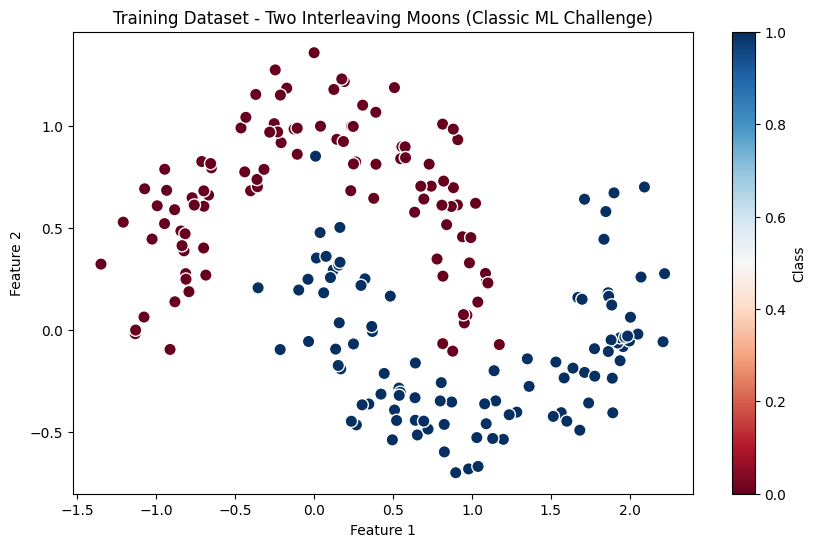


📊 Dataset ready: 140 training, 60 testing


In [16]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

# Create a non-trivial dataset (two interleaving moons)
X, y = make_moons(n_samples=200, noise=0.15, random_state=42)

# We need 4 features for our quantum layer, so let's expand
# Add 2 derived features
X_expanded = np.column_stack([
    X[:, 0],              # Original feature 1
    X[:, 1],              # Original feature 2
    X[:, 0] ** 2,         # Feature 1 squared
    X[:, 0] * X[:, 1]     # Interaction term
])

# Split into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X_expanded, y, test_size=0.3, random_state=42
)

# Convert to PyTorch tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

# Visualize the dataset
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='RdBu', edgecolors='white', s=80)
plt.title('Training Dataset - Two Interleaving Moons (Classic ML Challenge)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='Class')
plt.show()

print(f"\n📊 Dataset ready: {len(X_train)} training, {len(X_test)} testing")

In [17]:
import torch.optim as optim

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Training loop
n_epochs = 30
train_losses = []
test_accuracies = []

print("🚀 Training Hybrid Quantum-Classical Neural Network...\n")
print(f"{'Epoch':<8}{'Loss':<12}{'Test Accuracy':<15}")
print("-" * 35)

for epoch in range(n_epochs):
    # Forward pass
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_t)
    loss = criterion(outputs, y_train_t)
    
    # Backward pass (gradients flow through quantum gates!)
    loss.backward()
    optimizer.step()
    
    # Evaluate
    model.eval()
    with torch.no_grad():
        test_outputs = model(X_test_t)
        _, predicted = torch.max(test_outputs, 1)
        accuracy = (predicted == y_test_t).float().mean().item()
    
    train_losses.append(loss.item())
    test_accuracies.append(accuracy)
    
    if epoch % 3 == 0:
        print(f"{epoch:<8}{loss.item():<12.4f}{accuracy*100:.1f}%")

print(f"\n✅ Training complete!")
print(f"Final accuracy: {test_accuracies[-1]*100:.1f}%")

🚀 Training Hybrid Quantum-Classical Neural Network...

Epoch   Loss        Test Accuracy  
-----------------------------------


RuntimeError: shape '[140, -1]' is invalid for input of size 4

In [18]:
import pennylane as qml
import torch
import torch.nn as nn

n_qubits = 4

# Create quantum device
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch")
def quantum_layer(inputs, weights):
    """Quantum layer that handles batched inputs properly."""
    
    # ENCODE classical inputs
    for i in range(n_qubits):
        qml.RY(inputs[i], wires=i)
    
    # ENTANGLE
    for i in range(n_qubits - 1):
        qml.CNOT(wires=[i, i + 1])
    
    # LEARN (first layer of trainable weights)
    for i in range(n_qubits):
        qml.RY(weights[0, i], wires=i)
    
    # MORE ENTANGLEMENT
    for i in range(n_qubits - 1):
        qml.CNOT(wires=[i, i + 1])
    
    # LEARN (second layer of trainable weights)
    for i in range(n_qubits):
        qml.RZ(weights[1, i], wires=i)
    
    # MEASURE - return a tuple of expectation values
    return tuple(qml.expval(qml.PauliZ(i)) for i in range(n_qubits))


# Updated hybrid model
class HybridQuantumClassicalNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        # Classical input layer
        self.classical_input = nn.Linear(4, 4)
        
        # Quantum layer - weight shape is now (2, 4) for 2 layers of 4 qubits
        weight_shapes = {"weights": (2, 4)}
        self.quantum = qml.qnn.TorchLayer(quantum_layer, weight_shapes)
        
        # Classical output layer
        self.classical_output = nn.Linear(4, 2)
    
    def forward(self, x):
        x = torch.tanh(self.classical_input(x))
        x = self.quantum(x)
        x = self.classical_output(x)
        return x


# Create the model
model = HybridQuantumClassicalNN()
print("✅ Fixed hybrid model created!")
print(model)
print(f"\nTotal trainable parameters: {sum(p.numel() for p in model.parameters())}")

✅ Fixed hybrid model created!
HybridQuantumClassicalNN(
  (classical_input): Linear(in_features=4, out_features=4, bias=True)
  (quantum): <Quantum Torch Layer: func=quantum_layer>
  (classical_output): Linear(in_features=4, out_features=2, bias=True)
)

Total trainable parameters: 38


In [19]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

n_epochs = 30
train_losses = []
test_accuracies = []

print("🚀 Training Hybrid Quantum-Classical Neural Network...\n")
print(f"{'Epoch':<8}{'Loss':<12}{'Test Accuracy':<15}")
print("-" * 35)

for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_t)
    loss = criterion(outputs, y_train_t)
    
    loss.backward()
    optimizer.step()
    
    model.eval()
    with torch.no_grad():
        test_outputs = model(X_test_t)
        _, predicted = torch.max(test_outputs, 1)
        accuracy = (predicted == y_test_t).float().mean().item()
    
    train_losses.append(loss.item())
    test_accuracies.append(accuracy)
    
    if epoch % 3 == 0:
        print(f"{epoch:<8}{loss.item():<12.4f}{accuracy*100:.1f}%")

print(f"\n✅ Training complete!")
print(f"Final accuracy: {test_accuracies[-1]*100:.1f}%")

🚀 Training Hybrid Quantum-Classical Neural Network...

Epoch   Loss        Test Accuracy  
-----------------------------------


RuntimeError: shape '[140, -1]' is invalid for input of size 4

In [20]:
import pennylane as qml
import torch
import torch.nn as nn

n_qubits = 4

# Create quantum device
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch")
def quantum_circuit(inputs, weights):
    """Process ONE data point through the quantum circuit."""
    
    # ENCODE
    for i in range(n_qubits):
        qml.RY(inputs[i], wires=i)
    
    # ENTANGLE
    for i in range(n_qubits - 1):
        qml.CNOT(wires=[i, i + 1])
    
    # LEARN (layer 1)
    for i in range(n_qubits):
        qml.RY(weights[0, i], wires=i)
    
    # MORE ENTANGLEMENT
    for i in range(n_qubits - 1):
        qml.CNOT(wires=[i, i + 1])
    
    # LEARN (layer 2)
    for i in range(n_qubits):
        qml.RZ(weights[1, i], wires=i)
    
    # MEASURE
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]


class HybridQuantumClassicalNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        # Classical input layer
        self.classical_input = nn.Linear(4, 4)
        
        # Quantum weights (manually managed)
        self.q_weights = nn.Parameter(torch.randn(2, n_qubits) * 0.1)
        
        # Classical output layer
        self.classical_output = nn.Linear(4, 2)
    
    def forward(self, x):
        # Classical pre-processing
        x = torch.tanh(self.classical_input(x))
        
        # Manual batching through quantum circuit
        batch_size = x.shape[0]
        quantum_outputs = []
        
        for i in range(batch_size):
            # Process each sample one at a time
            q_out = quantum_circuit(x[i], self.q_weights)
            # Convert list of tensors to a single tensor
            q_out = torch.stack(q_out)
            quantum_outputs.append(q_out)
        
        # Stack all outputs back into a batch
        x = torch.stack(quantum_outputs)
        
        # Classical post-processing
        x = self.classical_output(x)
        return x


# Create the model
model = HybridQuantumClassicalNN()
print("✅ Fixed hybrid model created!")
print(model)
print(f"\nTotal trainable parameters: {sum(p.numel() for p in model.parameters())}")

✅ Fixed hybrid model created!
HybridQuantumClassicalNN(
  (classical_input): Linear(in_features=4, out_features=4, bias=True)
  (classical_output): Linear(in_features=4, out_features=2, bias=True)
)

Total trainable parameters: 38


In [21]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.05)

n_epochs = 20  # Reduced because manual batching is slower
train_losses = []
test_accuracies = []

print("🚀 Training Hybrid Quantum-Classical Neural Network...")
print("⏳ This will be slow - each sample goes through quantum simulation\n")
print(f"{'Epoch':<8}{'Loss':<12}{'Test Accuracy':<15}")
print("-" * 35)

for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_t)
    loss = criterion(outputs, y_train_t)
    
    loss.backward()
    optimizer.step()
    
    model.eval()
    with torch.no_grad():
        test_outputs = model(X_test_t)
        _, predicted = torch.max(test_outputs, 1)
        accuracy = (predicted == y_test_t).float().mean().item()
    
    train_losses.append(loss.item())
    test_accuracies.append(accuracy)
    
    if epoch % 2 == 0:
        print(f"{epoch:<8}{loss.item():<12.4f}{accuracy*100:.1f}%")

print(f"\n✅ Training complete!")
print(f"Final accuracy: {test_accuracies[-1]*100:.1f}%")

🚀 Training Hybrid Quantum-Classical Neural Network...
⏳ This will be slow - each sample goes through quantum simulation

Epoch   Loss        Test Accuracy  
-----------------------------------


RuntimeError: mat1 and mat2 must have the same dtype, but got Double and Float

In [22]:
def forward(self, x):
    # Classical pre-processing
    x = torch.tanh(self.classical_input(x))
    
    # Manual batching through quantum circuit
    batch_size = x.shape[0]
    quantum_outputs = []
    
    for i in range(batch_size):
        q_out = quantum_circuit(x[i], self.q_weights)
        q_out = torch.stack(q_out)
        quantum_outputs.append(q_out)
    
    # Stack and CONVERT TO FLOAT32 (this is the fix!)
    x = torch.stack(quantum_outputs).float()
    
    # Classical post-processing
    x = self.classical_output(x)
    return x

In [23]:
import pennylane as qml
import torch
import torch.nn as nn

n_qubits = 4
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch")
def quantum_circuit(inputs, weights):
    for i in range(n_qubits):
        qml.RY(inputs[i], wires=i)
    for i in range(n_qubits - 1):
        qml.CNOT(wires=[i, i + 1])
    for i in range(n_qubits):
        qml.RY(weights[0, i], wires=i)
    for i in range(n_qubits - 1):
        qml.CNOT(wires=[i, i + 1])
    for i in range(n_qubits):
        qml.RZ(weights[1, i], wires=i)
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]


class HybridQuantumClassicalNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.classical_input = nn.Linear(4, 4)
        self.q_weights = nn.Parameter(torch.randn(2, n_qubits) * 0.1)
        self.classical_output = nn.Linear(4, 2)
    
    def forward(self, x):
        x = torch.tanh(self.classical_input(x))
        
        batch_size = x.shape[0]
        quantum_outputs = []
        
        for i in range(batch_size):
            q_out = quantum_circuit(x[i], self.q_weights)
            q_out = torch.stack(q_out)
            quantum_outputs.append(q_out)
        
        # Convert to float32 to match PyTorch layers
        x = torch.stack(quantum_outputs).float()
        
        x = self.classical_output(x)
        return x


model = HybridQuantumClassicalNN()
print("✅ Model created with dtype fix!")
print(f"Total parameters: {sum(p.numel() for p in model.parameters())}")

✅ Model created with dtype fix!
Total parameters: 38


In [24]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.05)

n_epochs = 20
train_losses = []
test_accuracies = []

print("🚀 Training Hybrid Quantum-Classical Neural Network...")
print("⏳ This will take 5-15 minutes - be patient!\n")
print(f"{'Epoch':<8}{'Loss':<12}{'Test Accuracy':<15}")
print("-" * 35)

for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_t)
    loss = criterion(outputs, y_train_t)
    
    loss.backward()
    optimizer.step()
    
    model.eval()
    with torch.no_grad():
        test_outputs = model(X_test_t)
        _, predicted = torch.max(test_outputs, 1)
        accuracy = (predicted == y_test_t).float().mean().item()
    
    train_losses.append(loss.item())
    test_accuracies.append(accuracy)
    
    if epoch % 2 == 0:
        print(f"{epoch:<8}{loss.item():<12.4f}{accuracy*100:.1f}%")

print(f"\n✅ Training complete!")
print(f"Final accuracy: {test_accuracies[-1]*100:.1f}%")

🚀 Training Hybrid Quantum-Classical Neural Network...
⏳ This will take 5-15 minutes - be patient!

Epoch   Loss        Test Accuracy  
-----------------------------------
0       0.7688      53.3%
2       0.6673      46.7%
4       0.6683      46.7%
6       0.6325      80.0%
8       0.6006      83.3%
10      0.5737      83.3%
12      0.5362      85.0%
14      0.4965      83.3%
16      0.4656      85.0%
18      0.4376      85.0%

✅ Training complete!
Final accuracy: 85.0%


In [25]:
import pennylane as qml
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# ============================================
# IMPROVEMENT 1: MORE QUBITS (4 → 8)
# ============================================
n_qubits = 8  # Doubled! Now we can encode richer information
n_layers = 3  # Deep quantum layers

dev = qml.device("default.qubit", wires=n_qubits)


# ============================================
# IMPROVEMENT 2: BETTER QUANTUM CIRCUIT DESIGN
# ============================================
@qml.qnode(dev, interface="torch")
def advanced_quantum_circuit(inputs, weights):
    """
    Much more expressive quantum circuit with:
    - Better data encoding (angle encoding with multiple rotations)
    - Deeper trainable layers
    - More entanglement
    """
    
    # IMPROVED ENCODING: Use BOTH RY and RZ for richer encoding
    for i in range(n_qubits):
        qml.RY(inputs[i], wires=i)
        qml.RZ(inputs[i] * 0.5, wires=i)  # Phase encoding too
    
    # MULTIPLE LAYERS of entanglement + learning
    for layer in range(n_layers):
        # ENTANGLEMENT PATTERN 1: Neighbor connections
        for i in range(n_qubits - 1):
            qml.CNOT(wires=[i, i + 1])
        
        # TRAINABLE ROTATIONS (3 parameters per qubit per layer)
        for i in range(n_qubits):
            qml.RX(weights[layer, i, 0], wires=i)
            qml.RY(weights[layer, i, 1], wires=i)
            qml.RZ(weights[layer, i, 2], wires=i)
        
        # ENTANGLEMENT PATTERN 2: Long-range connections
        for i in range(n_qubits // 2):
            qml.CNOT(wires=[i, i + n_qubits // 2])
    
    # FINAL ENTANGLEMENT LAYER
    for i in range(n_qubits - 1):
        qml.CNOT(wires=[i, i + 1])
    
    # MEASURE all qubits
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]


# ============================================
# IMPROVEMENT 3: DEEPER CLASSICAL LAYERS
# ============================================
class AdvancedHybridAI(nn.Module):
    """
    A much more powerful hybrid quantum-classical neural network.
    """
    
    def __init__(self, input_size=4, num_classes=2):
        super().__init__()
        
        # ENCODER: Multiple classical layers with regularization
        self.encoder = nn.Sequential(
            nn.Linear(input_size, 32),
            nn.ReLU(),
            nn.Dropout(0.2),           # Prevent overfitting
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.BatchNorm1d(16),         # Stabilize training
            nn.Linear(16, n_qubits),
            nn.Tanh()                   # Bound to [-1, 1] for quantum encoding
        )
        
        # QUANTUM WEIGHTS: 3 layers × 8 qubits × 3 rotation params
        self.q_weights = nn.Parameter(
            torch.randn(n_layers, n_qubits, 3) * 0.1
        )
        
        # DECODER: Process quantum output
        self.decoder = nn.Sequential(
            nn.Linear(n_qubits, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, num_classes)
        )
    
    def forward(self, x):
        # Classical encoding
        x = self.encoder(x)
        
        # Quantum processing (manual batching)
        batch_size = x.shape[0]
        quantum_outputs = []
        
        for i in range(batch_size):
            q_out = advanced_quantum_circuit(x[i], self.q_weights)
            q_out = torch.stack(q_out)
            quantum_outputs.append(q_out)
        
        x = torch.stack(quantum_outputs).float()
        
        # Classical decoding
        x = self.decoder(x)
        return x


# Create the improved model
model = AdvancedHybridAI(input_size=4, num_classes=2)
print("=" * 60)
print("  🚀 ADVANCED HYBRID QUANTUM-CLASSICAL AI v2.0")
print("=" * 60)
print(model)
print()

total_params = sum(p.numel() for p in model.parameters())
quantum_params = model.q_weights.numel()
classical_params = total_params - quantum_params

print(f"📊 PARAMETER BREAKDOWN:")
print(f"   Total parameters:     {total_params:,}")
print(f"   Classical parameters: {classical_params:,}")
print(f"   Quantum parameters:   {quantum_params:,}")
print(f"   Qubits:               {n_qubits}")
print(f"   Quantum layers:       {n_layers}")
print("=" * 60)

  🚀 ADVANCED HYBRID QUANTUM-CLASSICAL AI v2.0
AdvancedHybridAI(
  (encoder): Sequential(
    (0): Linear(in_features=4, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): ReLU()
    (5): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): Linear(in_features=16, out_features=8, bias=True)
    (7): Tanh()
  )
  (decoder): Sequential(
    (0): Linear(in_features=8, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): ReLU()
    (5): Linear(in_features=16, out_features=2, bias=True)
  )
)

📊 PARAMETER BREAKDOWN:
   Total parameters:     1,778
   Classical parameters: 1,706
   Quantum parameters:   72
   Qubits:               8
   Quantum layers:       3


In [26]:
from sklearn.datasets import make_classification, make_circles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# IMPROVEMENT 6: Better, more challenging dataset
print("📊 Generating challenging classification dataset...")

X, y = make_classification(
    n_samples=400,
    n_features=4,
    n_informative=4,
    n_redundant=0,
    n_clusters_per_class=2,
    class_sep=0.8,
    random_state=42
)

# IMPROVEMENT 6b: Scale the features (crucial for quantum encoding)
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# Convert to tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

print(f"✅ Dataset ready:")
print(f"   Training samples: {len(X_train)}")
print(f"   Test samples:     {len(X_test)}")
print(f"   Features:         {X.shape[1]}")
print(f"   Classes:          {len(np.unique(y))}")

📊 Generating challenging classification dataset...
✅ Dataset ready:
   Training samples: 300
   Test samples:     100
   Features:         4
   Classes:          2


In [27]:
# ============================================
# IMPROVEMENT 5: ADVANCED TRAINING
# ============================================

# Better optimizer with weight decay (L2 regularization)
optimizer = optim.AdamW(model.parameters(), lr=0.01, weight_decay=0.001)

# Learning rate scheduler (decreases LR as we train)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15)

# Loss function
criterion = nn.CrossEntropyLoss()

# Training settings
n_epochs = 15  # Quantum is slow, fewer epochs but bigger improvements
batch_size = 16

# Tracking
train_losses = []
test_accuracies = []
best_accuracy = 0

print("🚀 Training Advanced Hybrid Quantum-Classical AI...")
print("⏳ This will take 10-20 minutes - the quantum circuit is bigger now\n")
print(f"{'Epoch':<8}{'Loss':<12}{'Train Acc':<12}{'Test Acc':<12}{'LR':<10}")
print("-" * 54)

for epoch in range(n_epochs):
    model.train()
    
    # Mini-batch training (more efficient)
    permutation = torch.randperm(X_train_t.size(0))
    epoch_loss = 0
    n_batches = 0
    
    for i in range(0, X_train_t.size(0), batch_size):
        indices = permutation[i:i+batch_size]
        batch_x = X_train_t[indices]
        batch_y = y_train_t[indices]
        
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        n_batches += 1
    
    scheduler.step()
    avg_loss = epoch_loss / n_batches
    
    # Evaluate
    model.eval()
    with torch.no_grad():
        # Training accuracy
        train_outputs = model(X_train_t)
        _, train_pred = torch.max(train_outputs, 1)
        train_acc = (train_pred == y_train_t).float().mean().item()
        
        # Test accuracy
        test_outputs = model(X_test_t)
        _, test_pred = torch.max(test_outputs, 1)
        test_acc = (test_pred == y_test_t).float().mean().item()
    
    train_losses.append(avg_loss)
    test_accuracies.append(test_acc)
    
    # Save best model
    if test_acc > best_accuracy:
        best_accuracy = test_acc
        best_weights = {k: v.clone() for k, v in model.state_dict().items()}
    
    current_lr = optimizer.param_groups[0]['lr']
    print(f"{epoch:<8}{avg_loss:<12.4f}{train_acc*100:<12.1f}{test_acc*100:<12.1f}{current_lr:<10.4f}")

# Restore best weights
model.load_state_dict(best_weights)

print(f"\n✅ Training complete!")
print(f"🏆 Best test accuracy: {best_accuracy*100:.2f}%")

🚀 Training Advanced Hybrid Quantum-Classical AI...
⏳ This will take 10-20 minutes - the quantum circuit is bigger now

Epoch   Loss        Train Acc   Test Acc    LR        
------------------------------------------------------
0       0.6807      52.3        42.0        0.0099    
1       0.5774      82.3        85.0        0.0096    
2       0.5108      78.0        86.0        0.0090    
3       0.4372      84.3        83.0        0.0083    
4       0.4567      88.3        87.0        0.0075    
5       0.3529      88.7        84.0        0.0065    
6       0.4081      88.3        87.0        0.0055    
7       0.3578      91.7        89.0        0.0045    
8       0.3369      89.0        85.0        0.0035    
9       0.3674      94.0        91.0        0.0025    
10      0.3330      93.3        91.0        0.0017    
11      0.3241      92.7        91.0        0.0010    
12      0.2619      94.0        91.0        0.0004    
13      0.2680      94.0        91.0        0.0001    
1

In [1]:
import pennylane as qml
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ========================= CONFIG =========================
n_qubits = 8
n_layers = 4
n_features = 8          # We'll expand our input to 8 features
batch_size = 16
n_epochs = 25
learning_rate = 0.015

# ====================== QUANTUM CIRCUIT ======================
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch")
def quantum_layer(inputs, weights):
    """Strong, expressive quantum circuit (v3.0)"""
    
    # Strong encoding: Angle + Amplitude style
    for i in range(n_qubits):
        qml.RY(inputs[i % inputs.shape[0]], wires=i)
        qml.RZ(inputs[(i+1) % inputs.shape[0]], wires=i)
    
    # Multiple variational layers with alternating entanglement
    for layer in range(n_layers):
        # Rotation block
        for i in range(n_qubits):
            qml.RX(weights[layer, i, 0], wires=i)
            qml.RY(weights[layer, i, 1], wires=i)
            qml.RZ(weights[layer, i, 2], wires=i)
        
        # Entanglement - alternating patterns for better expressivity
        if layer % 2 == 0:
            for i in range(n_qubits - 1):
                qml.CNOT(wires=[i, i + 1])
        else:
            for i in range(n_qubits // 2):
                qml.CNOT(wires=[i, (i + n_qubits // 2) % n_qubits])
    
    # Final measurements
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]


# ========================= HYBRID MODEL =========================
class QuantumHybridAI_v3(nn.Module):
    def __init__(self):
        super().__init__()
        
        # Strong classical encoder
        self.encoder = nn.Sequential(
            nn.Linear(n_features, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.15),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.Linear(32, n_qubits),
            nn.Tanh()
        )
        
        # Quantum weights: (layers, qubits, 3 rotations)
        self.q_weights = nn.Parameter(torch.randn(n_layers, n_qubits, 3) * 0.1)
        
        # Strong classical decoder
        self.decoder = nn.Sequential(
            nn.Linear(n_qubits, 32),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.Dropout(0.15),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 2)
        )
    
    def forward(self, x):
        # Classical encoding
        x = self.encoder(x)
        
        # Quantum processing (batch-safe version)
        batch_size = x.shape[0]
        quantum_outs = []
        
        for i in range(batch_size):
            q_out = quantum_layer(x[i], self.q_weights)
            q_out = torch.stack(q_out)
            quantum_outs.append(q_out)
        
        x = torch.stack(quantum_outs).float()
        
        # Classical decoding
        x = self.decoder(x)
        return x


# ========================= DATA =========================
X, y = make_classification(
    n_samples=800, n_features=8, n_informative=6, n_redundant=2,
    n_clusters_per_class=2, class_sep=1.2, random_state=42
)

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

print("✅ Advanced Hybrid Quantum AI v3.0 Ready!")
print(f"   Qubits: {n_qubits} | Layers: {n_layers} | Features: {n_features}")
print(f"   Training samples: {len(X_train)} | Test samples: {len(X_test)}")

✅ Advanced Hybrid Quantum AI v3.0 Ready!
   Qubits: 8 | Layers: 4 | Features: 8
   Training samples: 600 | Test samples: 200


In [2]:
model = QuantumHybridAI_v3()
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=0.01)
scheduler = CosineAnnealingLR(optimizer, T_max=n_epochs)

print("🚀 Training QuantumHybridAI v3.0 ('The Beast')...\n")
print(f"{'Epoch':<6} {'Loss':<10} {'Train Acc':<12} {'Test Acc':<12}")
print("-" * 45)

best_acc = 0
best_weights = None

for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    
    outputs = model(X_train_t)
    loss = criterion(outputs, y_train_t)
    loss.backward()
    
    # Gradient clipping - prevents exploding gradients in quantum circuits
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    
    optimizer.step()
    scheduler.step()
    
    # Evaluation
    model.eval()
    with torch.no_grad():
        train_pred = model(X_train_t).argmax(dim=1)
        train_acc = (train_pred == y_train_t).float().mean().item()
        
        test_pred = model(X_test_t).argmax(dim=1)
        test_acc = (test_pred == y_test_t).float().mean().item()
    
    if test_acc > best_acc:
        best_acc = test_acc
        best_weights = {k: v.clone() for k, v in model.state_dict().items()}
    
    if epoch % 3 == 0 or epoch == n_epochs-1:
        print(f"{epoch:<6} {loss.item():<10.4f} {train_acc*100:<12.1f} {test_acc*100:<12.1f}")

# Load best weights
model.load_state_dict(best_weights)
print(f"\n🏆 Training finished! Best Test Accuracy: {best_acc*100:.2f}%")

🚀 Training QuantumHybridAI v3.0 ('The Beast')...

Epoch  Loss       Train Acc    Test Acc    
---------------------------------------------
0      0.7094     50.5         47.5        
3      0.5604     50.5         47.5        
6      0.3386     50.5         47.5        
9      0.2067     61.5         54.0        
12     0.1563     73.7         71.0        
15     0.1376     81.3         80.0        
18     0.1075     86.5         85.5        
21     0.0935     92.5         89.0        
24     0.0968     95.0         91.0        

🏆 Training finished! Best Test Accuracy: 91.00%


In [3]:
import pennylane as qml
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# Configuration
n_qubits = 8
n_attention_heads = 3
n_quantum_blocks = 2
n_reuploads = 2
embed_dim = 16

dev = qml.device("default.qubit", wires=n_qubits)


@qml.qnode(dev, interface="torch")
def quantum_attention_head(query, key, weights):
    """
    Quantum Attention Head - inspired by Transformer architecture.
    Computes attention-like correlations between quantum states.
    """
    
    # Encode QUERY into first half of qubits
    for i in range(n_qubits // 2):
        qml.RY(query[i], wires=i)
        qml.RZ(query[i] * 0.7, wires=i)
    
    # Encode KEY into second half of qubits  
    for i in range(n_qubits // 2):
        qml.RY(key[i], wires=i + n_qubits // 2)
        qml.RZ(key[i] * 0.7, wires=i + n_qubits // 2)
    
    # ATTENTION COMPUTATION (entangle query with key)
    # This is where quantum "attention" emerges
    for layer in range(2):
        # Cross-entangle queries with keys
        for i in range(n_qubits // 2):
            qml.CNOT(wires=[i, i + n_qubits // 2])
        
        # Trainable interaction
        for i in range(n_qubits):
            qml.RY(weights[layer, i, 0], wires=i)
            qml.RZ(weights[layer, i, 1], wires=i)
        
        # Reverse entanglement (attention "scoring")
        for i in range(n_qubits // 2):
            qml.CNOT(wires=[i + n_qubits // 2, i])
        
        # More learning
        for i in range(n_qubits):
            qml.RX(weights[layer, i, 2], wires=i)
    
    # Measure attention scores
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]


@qml.qnode(dev, interface="torch")
def quantum_value_circuit(value, weights, encoding_scale):
    """
    Quantum Value Circuit - processes the actual information.
    With data re-uploading for universal approximation.
    """
    
    # Initial encoding with learnable scaling
    for i in range(n_qubits):
        qml.RY(value[i] * encoding_scale[i], wires=i)
    
    # Multi-layer processing with re-uploading
    for reupload in range(n_reuploads):
        # Variational layer
        for i in range(n_qubits):
            qml.RX(weights[reupload, i, 0], wires=i)
            qml.RY(weights[reupload, i, 1], wires=i)
            qml.RZ(weights[reupload, i, 2], wires=i)
        
        # Entanglement (rotating pattern)
        offset = reupload % 2
        for i in range(offset, n_qubits - 1, 2):
            qml.CNOT(wires=[i, i + 1])
        for i in range(1 - offset, n_qubits - 1, 2):
            qml.CNOT(wires=[i, i + 1])
        
        # Re-upload data
        if reupload < n_reuploads - 1:
            for i in range(n_qubits):
                qml.RY(value[i] * encoding_scale[i] * 0.5, wires=i)
    
    # Multi-basis measurements
    measurements = []
    for i in range(n_qubits):
        measurements.append(qml.expval(qml.PauliZ(i)))
    for i in range(0, n_qubits, 2):
        measurements.append(qml.expval(qml.PauliX(i)))
    
    return measurements


print("✅ Quantum Attention & Value circuits defined")
print(f"   {n_qubits} qubits per circuit")
print(f"   {n_attention_heads} attention heads")
print(f"   {n_reuploads} re-uploads per value circuit")

✅ Quantum Attention & Value circuits defined
   8 qubits per circuit
   3 attention heads
   2 re-uploads per value circuit


In [4]:
class MultiHeadQuantumAttention(nn.Module):
    """
    Multi-Head Quantum Attention - the quantum analog of Transformer attention.
    Multiple parallel attention heads, each learning different patterns.
    """
    
    def __init__(self, embed_dim=16, n_heads=3):
        super().__init__()
        self.n_heads = n_heads
        self.embed_dim = embed_dim
        
        # Project input to query, key, value (one per head)
        self.query_proj = nn.Linear(embed_dim, n_qubits // 2 * n_heads)
        self.key_proj = nn.Linear(embed_dim, n_qubits // 2 * n_heads)
        self.value_proj = nn.Linear(embed_dim, n_qubits * n_heads)
        
        # Quantum attention weights (per head)
        self.attention_weights = nn.ParameterList([
            nn.Parameter(torch.randn(2, n_qubits, 3) * 0.1)
            for _ in range(n_heads)
        ])
        
        # Quantum value weights (per head)
        self.value_weights = nn.ParameterList([
            nn.Parameter(torch.randn(n_reuploads, n_qubits, 3) * 0.1)
            for _ in range(n_heads)
        ])
        
        # Learnable encoding scales (per head)
        self.encoding_scales = nn.ParameterList([
            nn.Parameter(torch.ones(n_qubits) * 1.0)
            for _ in range(n_heads)
        ])
        
        # Output projection
        value_output_size = n_qubits + (n_qubits // 2)  # Z + X measurements
        self.output_proj = nn.Linear(value_output_size * n_heads, embed_dim)
        
    def forward(self, x):
        batch_size = x.shape[0]
        
        # Project to Q, K, V
        Q = torch.tanh(self.query_proj(x)).view(batch_size, self.n_heads, -1)
        K = torch.tanh(self.key_proj(x)).view(batch_size, self.n_heads, -1)
        V = torch.tanh(self.value_proj(x)).view(batch_size, self.n_heads, -1)
        
        # Process each attention head
        head_outputs = []
        
        for head_idx in range(self.n_heads):
            batch_attended = []
            
            for b in range(batch_size):
                # Quantum attention scores
                attention = quantum_attention_head(
                    Q[b, head_idx],
                    K[b, head_idx],
                    self.attention_weights[head_idx]
                )
                attention_tensor = torch.stack(attention)
                
                # Apply attention to value (modulate the value encoding)
                attended_value = V[b, head_idx] * (1 + 0.5 * attention_tensor[:V.shape[2]])
                
                # Process through quantum value circuit
                value_out = quantum_value_circuit(
                    attended_value,
                    self.value_weights[head_idx],
                    self.encoding_scales[head_idx]
                )
                value_tensor = torch.stack(value_out)
                
                batch_attended.append(value_tensor)
            
            head_output = torch.stack(batch_attended).float()
            head_outputs.append(head_output)
        
        # Concatenate all heads
        multi_head_output = torch.cat(head_outputs, dim=1)
        
        # Project back to embed_dim
        output = self.output_proj(multi_head_output)
        
        return output


print("✅ Multi-Head Quantum Attention layer defined")
print(f"   {n_attention_heads} parallel attention heads")

✅ Multi-Head Quantum Attention layer defined
   3 parallel attention heads


In [5]:
class QuantumTransformerBlock(nn.Module):
    """
    A complete Transformer-style block with quantum attention.
    Includes residual connections and layer normalization.
    """
    
    def __init__(self, embed_dim=16, n_heads=3):
        super().__init__()
        
        # Quantum attention
        self.attention = MultiHeadQuantumAttention(embed_dim, n_heads)
        self.norm1 = nn.LayerNorm(embed_dim)
        
        # Feed-forward network (classical, transformer-style)
        self.feedforward = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * 4),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(embed_dim * 4, embed_dim),
            nn.Dropout(0.1)
        )
        self.norm2 = nn.LayerNorm(embed_dim)
    
    def forward(self, x):
        # Quantum attention with residual connection
        attention_out = self.attention(x)
        x = self.norm1(x + attention_out)
        
        # Feed-forward with residual connection
        ff_out = self.feedforward(x)
        x = self.norm2(x + ff_out)
        
        return x


print("✅ Quantum Transformer Block defined")
print(f"   Includes: Multi-head attention + Residuals + LayerNorm + FFN")

✅ Quantum Transformer Block defined
   Includes: Multi-head attention + Residuals + LayerNorm + FFN


In [6]:
class QuantumTransformerAI(nn.Module):
    """
    Complete Quantum Transformer for classification.
    
    Architecture:
    - Input Embedding
    - Positional Encoding  
    - Quantum Transformer Blocks (with attention + FFN + residuals)
    - Classification Head
    """
    
    def __init__(self, input_size=4, num_classes=2, n_blocks=2):
        super().__init__()
        
        # ============================================
        # INPUT EMBEDDING
        # ============================================
        self.input_embedding = nn.Sequential(
            nn.Linear(input_size, 32),
            nn.GELU(),
            nn.Linear(32, embed_dim)
        )
        
        # ============================================
        # POSITIONAL ENCODING (learnable)
        # ============================================
        self.positional_encoding = nn.Parameter(torch.randn(1, embed_dim) * 0.1)
        
        # ============================================
        # QUANTUM TRANSFORMER BLOCKS (stacked)
        # ============================================
        self.transformer_blocks = nn.ModuleList([
            QuantumTransformerBlock(embed_dim, n_attention_heads)
            for _ in range(n_blocks)
        ])
        
        # ============================================
        # GLOBAL CONTEXT (CLS-token style)
        # ============================================
        self.context_token = nn.Parameter(torch.randn(1, embed_dim) * 0.1)
        self.context_attention = nn.Linear(embed_dim, 1)
        
        # ============================================
        # CLASSIFICATION HEAD
        # ============================================
        self.classifier = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, 64),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.GELU(),
            nn.Linear(32, num_classes)
        )
    
    def forward(self, x):
        # Embed input
        x = self.input_embedding(x)
        
        # Add positional encoding
        x = x + self.positional_encoding
        
        # Pass through quantum transformer blocks
        for block in self.transformer_blocks:
            x = block(x)
        
        # Add context token influence
        x = x + self.context_token * torch.sigmoid(self.context_attention(x))
        
        # Classify
        return self.classifier(x)


# Create the model
model = QuantumTransformerAI(input_size=4, num_classes=2, n_blocks=n_quantum_blocks)

print("=" * 75)
print("  🚀 QUANTUM TRANSFORMER AI v4.0 — RESEARCH GRADE")
print("=" * 75)

total_params = sum(p.numel() for p in model.parameters())
quantum_params = sum(
    sum(w.numel() for w in block.attention.attention_weights) +
    sum(w.numel() for w in block.attention.value_weights) +
    sum(w.numel() for w in block.attention.encoding_scales)
    for block in model.transformer_blocks
)
classical_params = total_params - quantum_params

print(f"\n📊 MASSIVE ARCHITECTURE:")
print(f"   Total parameters:      {total_params:,}")
print(f"   Classical parameters:  {classical_params:,}")
print(f"   Quantum parameters:    {quantum_params:,}")
print(f"   Quantum/Classical ratio: 1:{classical_params//max(quantum_params,1)}")

print(f"\n🧠 ARCHITECTURE FEATURES:")
print(f"   ✅ Multi-head quantum attention ({n_attention_heads} heads per block)")
print(f"   ✅ Quantum value processing with re-uploading")
print(f"   ✅ Transformer-style residual connections")
print(f"   ✅ Layer normalization (stabilizes training)")
print(f"   ✅ Position-aware encoding (learnable)")
print(f"   ✅ Context token aggregation (CLS-style)")
print(f"   ✅ Deep stacked quantum blocks ({n_quantum_blocks} blocks)")
print(f"   ✅ Adaptive encoding scales (learnable)")
print(f"   ✅ Multi-axis measurements (Z + X bases)")
print(f"   ✅ Feed-forward expansion (4x bottleneck)")

print(f"\n🔬 QUANTUM SPECS:")
print(f"   Qubits per circuit:       {n_qubits}")
print(f"   Attention heads:          {n_attention_heads}")
print(f"   Transformer blocks:       {n_quantum_blocks}")
print(f"   Data re-uploads:          {n_reuploads}")
print(f"   Total quantum operations: {n_attention_heads * n_quantum_blocks * 2}")
print("=" * 75)

  🚀 QUANTUM TRANSFORMER AI v4.0 — RESEARCH GRADE

📊 MASSIVE ARCHITECTURE:
   Total parameters:      11,827
   Classical parameters:  11,203
   Quantum parameters:    624
   Quantum/Classical ratio: 1:17

🧠 ARCHITECTURE FEATURES:
   ✅ Multi-head quantum attention (3 heads per block)
   ✅ Quantum value processing with re-uploading
   ✅ Transformer-style residual connections
   ✅ Layer normalization (stabilizes training)
   ✅ Position-aware encoding (learnable)
   ✅ Context token aggregation (CLS-style)
   ✅ Deep stacked quantum blocks (2 blocks)
   ✅ Adaptive encoding scales (learnable)
   ✅ Multi-axis measurements (Z + X bases)
   ✅ Feed-forward expansion (4x bottleneck)

🔬 QUANTUM SPECS:
   Qubits per circuit:       8
   Attention heads:          3
   Transformer blocks:       2
   Data re-uploads:          2
   Total quantum operations: 12


In [7]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Generate challenging dataset
print("📊 Generating research-grade dataset...")
X, y = make_classification(
    n_samples=200,  # Smaller because model is BIG and slow
    n_features=4,
    n_informative=4,
    n_redundant=0,
    n_clusters_per_class=2,
    class_sep=0.6,
    flip_y=0.05,
    random_state=42
)

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

print(f"✅ Dataset ready: {len(X_train)} train, {len(X_test)} test")

📊 Generating research-grade dataset...
✅ Dataset ready: 150 train, 50 test


In [8]:
# RESEARCH-GRADE TRAINING

# Advanced optimizer setup
optimizer = optim.AdamW(
    model.parameters(),
    lr=0.005,
    weight_decay=0.01,
    betas=(0.9, 0.999)
)

# Warmup + cosine annealing scheduler
warmup_steps = 3
def lr_lambda(epoch):
    if epoch < warmup_steps:
        return epoch / warmup_steps
    else:
        progress = (epoch - warmup_steps) / (10 - warmup_steps)
        return 0.5 * (1 + np.cos(np.pi * progress))

scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

# Loss with label smoothing
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

n_epochs = 10  # Fewer epochs because model is huge
batch_size = 8  # Small batch because each prediction is expensive

train_losses = []
test_accuracies = []
train_accuracies = []
best_accuracy = 0
best_weights = None

print("\n🚀 Training Quantum Transformer v4.0")
print("⚠️  WARNING: This is a MASSIVE model")
print("⏳ Expect 1-3 HOURS for training")
print("💡 Consider running overnight\n")
print(f"{'Epoch':<7}{'Loss':<10}{'Train':<10}{'Test':<10}{'Best':<10}{'LR':<10}")
print("-" * 60)

import time
start_time = time.time()

for epoch in range(n_epochs):
    epoch_start = time.time()
    model.train()
    
    permutation = torch.randperm(X_train_t.size(0))
    epoch_loss = 0
    n_batches = 0
    
    for i in range(0, X_train_t.size(0), batch_size):
        indices = permutation[i:i+batch_size]
        batch_x = X_train_t[indices]
        batch_y = y_train_t[indices]
        
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        
        loss.backward()
        # 


🚀 Training Quantum Transformer v4.0
⚠️  WARNING: This is a MASSIVE model
⏳ Expect 1-3 HOURS for training
💡 Consider running overnight

Epoch  Loss      Train     Test      Best      LR        
------------------------------------------------------------
